# Neural Jastrow

In this tutorial, we use neural networks as generalized Jastrow factors to study the Heisenberg J1-J2 model.

Reference:

[Y. Nomura et al., Restricted Boltzmann machine learning for solving strongly correlated quantum systems, Phys. Rev. B 96, 205152 (2017).](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.96.205152)

[Y. Nomura and M. Imada, Dirac-Type Nodal Spin Liquid Revealed by Refined Quantum Many-Body Solver Using Neural-Network Wave Function, Correlation Ratio, and Level Spectroscopy, Phys. Rev. X 11, 031034 (2021).](https://journals.aps.org/prx/abstract/10.1103/PhysRevX.11.031034)

In [1]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import quantax as qtx
from IPython.display import clear_output

qtx.set_default_dtype(jnp.float64)

lattice = qtx.sites.Square(4, Nparticles=(8, 8))

The Hamiltonian is

$$
H = J_1 \sum_{\braket{ij}} \mathbf{\sigma}_i \cdot \mathbf{\sigma}_j
+ J_2 \sum_{\braket{\braket{ij}}} \mathbf{\sigma}_i \cdot \mathbf{\sigma}_j,
$$

where $\braket{ij}$ and $\braket{\braket{ij}}$ represent nearest and next-nearest neighbors, respectively. 

In [2]:
from quantax.symmetry import Identity, TransND, C4v, SpinInverse

H = qtx.operator.Heisenberg(J=[1, 0.5], n_neighbor=[1, 2])

full_symm = TransND() @ C4v() @ SpinInverse()
E, psi = H.diagonalize(symm=full_symm)
exact_energy = E[0]
exact_state = qtx.state.DenseState(psi, full_symm)
print("Exact ground state energy:", exact_energy)

/home/aochen/quantax/quantax/symmetry/symmetry.py:330: GeneralBasisWarning: using non-commuting symmetries can lead to unwanted behaviour of general basis, make sure that quantum numbers are invariant under non-commuting symmetries!
  basis = spin_basis_general(


Exact ground state energy: -33.831693405579394


## Gutzwiller-projected fermionic wavefunction

The Hamiltonian in spin degrees of freedom can be mapped to fermion ones by

$$
S^\alpha = \frac{1}{2} (c_\uparrow^\dagger, c_\downarrow^\dagger) \sigma^\alpha
\begin{pmatrix} c_\uparrow \\ c_\downarrow \end{pmatrix},
$$

where $\alpha = x,y,z$ and $\sigma^\alpha$ are Pauli matrices. Quantax utilizes this relation internally such that fermionic mean-field states can be optimized in spin systems.

A fermionic wavefunction $\ket{\psi_0}$ contains redundancy of zero occupancy and double occupancy when it is used for spin systems. Therefore, one needs a Gutzwiller projection to obtain

$$
\ket{\psi_G} = \hat P_G \ket{\psi_0},
$$

where $\hat P_G = \prod_i (n_{i\uparrow} - n_{i\downarrow})^2$ projects the state to spin degrees of freedom. In variational Monte Carlo, this is done by sampling suitable sectors instead of modifying the mean-field state.

Here we show how to optimize the Gutzwiller-projected fermionic mean-field wavefunction. {py:class}`~quantax.state.GeneralPfState` is a subclass of {py:class}`~quantax.state.Variational`, so one can train it directly with {py:class}`~quantax.optimizer.SR`.

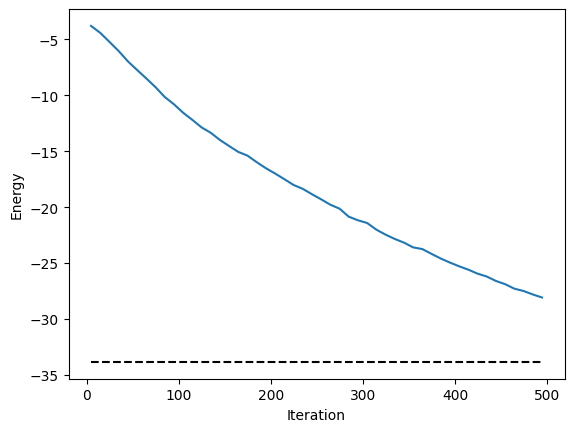

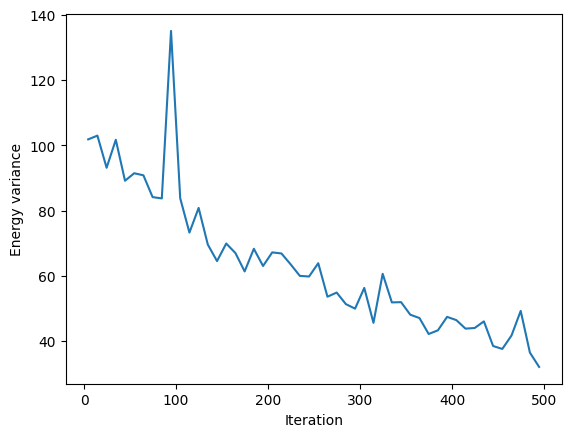

In [3]:
mf_state = qtx.state.GeneralPfState(max_parallel=32768)
sampler = qtx.sampler.SpinExchange(mf_state, 1024, n_neighbor=[1, 2])
optimizer = qtx.optimizer.SR(mf_state, H)

energy = qtx.utils.DataTracer()
VarE = qtx.utils.DataTracer()

for i in range(500):
    samples = sampler.sweep()
    step = optimizer.get_step(samples)
    mf_state.update(step * 1e-3)

    energy.append(optimizer.energy)
    VarE.append(optimizer.VarE)

energy.plot(batch=10, baseline=exact_energy)
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.show()
VarE.plot(batch=10)
plt.xlabel("Iteration")
plt.ylabel("Energy variance")
plt.show()

## Standard Jastrow factor

A standard Jastrow factor multiplies an existing wavefunction by a configuration-dependent weight,

$$
\psi(s) = J(s) \psi_G(s),
$$

where $\psi_G(s)$ is the Gutzwiller-projected Pfaffian optimized above. The traditional two-body Jastrow factor {py:class}`~quantax.model.Jastrow` reads

$$
J(s) = \exp\left(\frac{1}{2} \sum_{ij} W_{ij}\, s_i s_j\right),
$$

with $s_i = \pm 1$ and a symmetric coupling matrix $W$ of variational parameters.

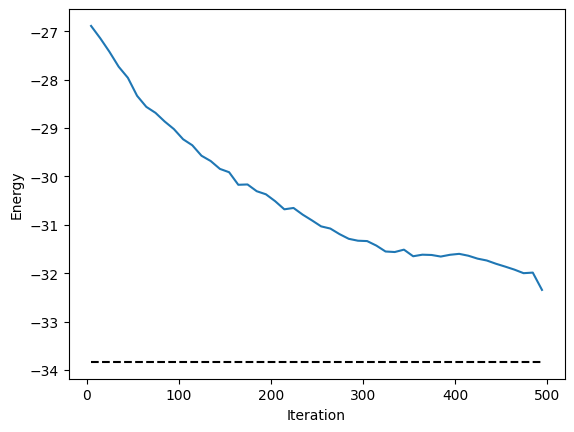

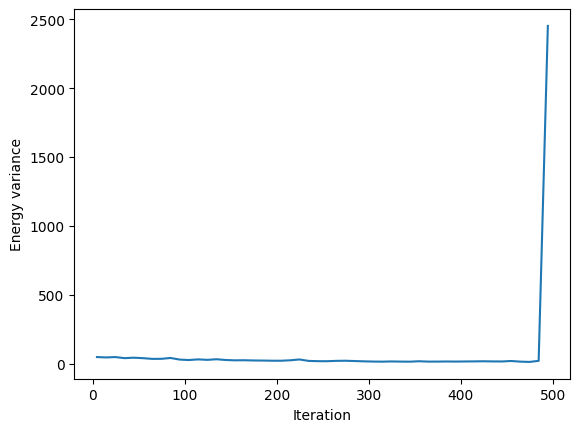

In [4]:
jastrow = qtx.model.Jastrow()
model = qtx.model.GeneralJastrow(net=jastrow, fermion_mf=mf_state.model)

state = qtx.state.Variational(model, max_parallel=16384)
sampler = qtx.sampler.SpinExchange(state, 1024, n_neighbor=[1, 2])
optimizer = qtx.optimizer.SR(state, H)

energy = qtx.utils.DataTracer()
VarE = qtx.utils.DataTracer()

for i in range(500):
    samples = sampler.sweep()
    step = optimizer.get_step(samples)
    state.update(step * 5e-4)

    energy.append(optimizer.energy)
    VarE.append(optimizer.VarE)

energy.plot(batch=10, baseline=exact_energy)
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.show()
VarE.plot(batch=10)
plt.xlabel("Iteration")
plt.ylabel("Energy variance")
plt.show()

## Neural Jastrow factor

We can make the Jastrow factor far more expressive by replacing the simple two-body form with a neural network, keeping the same structure

$$
\psi(s) = J(s) \psi_G(s),
$$

where $J(s)$ is now the neural Jastrow factor and $\psi_G(s)$ is the Gutzwiller-projected fermionic wavefunction. We reuse the pre-trained Pfaffian model `mf_state.model` as a good initialization.

We utilize {py:class}`~quantax.model.ResConv` as the neural network. `trans_symm=Identity()` means the network output is not summed in the last layer, so the output is a matrix $\mathbf{J}(s)$. Then we define {py:class}`~quantax.model.GeneralJastrow` with `trans_symm=TransND()`, which means the output is

$$
\psi(s) = \sum_i^{L_x} \sum_j^{L_y} \mathbf{J}_{ij}(s) \psi_G(T_{ij}s),
$$

where $T_{ij}s$ is a translation of the original input $s$. One can view this formula as a translation symmetrized form of $\psi(s) = J(s) \psi_G(s)$.

In [5]:
net = qtx.model.ResConv(nblocks=2, channels=8, kernel_size=3, trans_symm=Identity())
model = qtx.model.GeneralJastrow(net, mf_state.model, trans_symm=TransND())

Then one can perform the usual SR optimization on this wavefunction.

In [6]:
state = qtx.state.Variational(model, max_parallel=16384)

sampler = qtx.sampler.SpinExchange(state, 1024, n_neighbor=[1, 2])
optimizer = qtx.optimizer.SR(state, H)

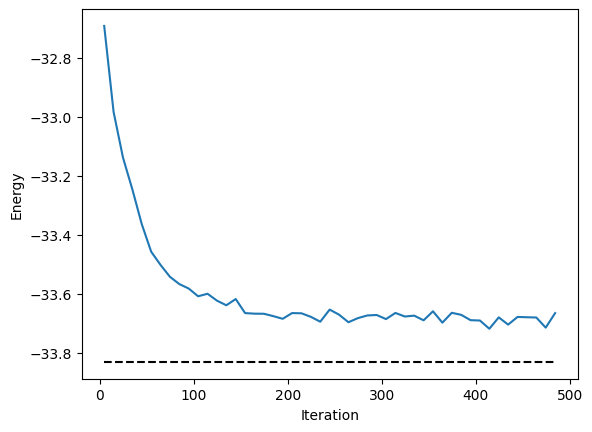

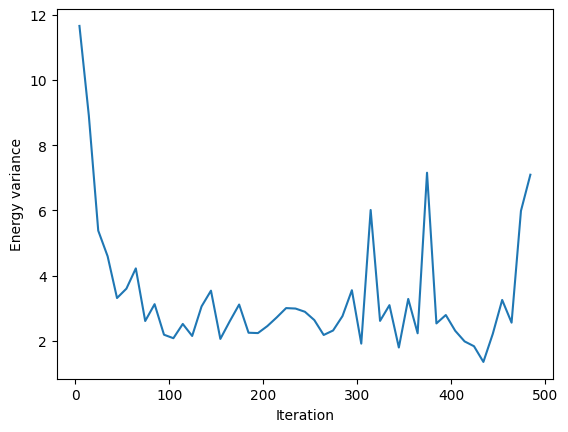

In [7]:
energy = qtx.utils.DataTracer()
VarE = qtx.utils.DataTracer()

for i in range(500):
    samples = sampler.sweep()
    step = optimizer.get_step(samples)
    state.update(step * 2e-3)

    energy.append(optimizer.energy)
    VarE.append(optimizer.VarE)

    if i % 10 == 0:
        clear_output(wait=True)
        energy.plot(batch=10, baseline=exact_energy)
        plt.xlabel("Iteration")
        plt.ylabel("Energy")
        plt.show()
        VarE.plot(batch=10)
        plt.xlabel("Iteration")
        plt.ylabel("Energy variance")
        plt.show()

state.save("/tmp/neural_jastrow.eqx")

This state can also be symmetrized to achieve better accuracy.

In [8]:
symm = C4v() @ SpinInverse()
state = qtx.state.Variational(
    model, param_file="/tmp/neural_jastrow.eqx", symm=symm, max_parallel=2048
)

sampler = qtx.sampler.SpinExchange(state, 1024, n_neighbor=[1, 2])
optimizer = qtx.optimizer.SR(state, H)

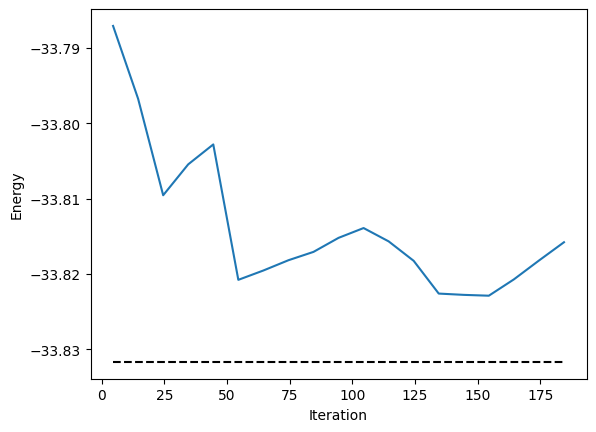

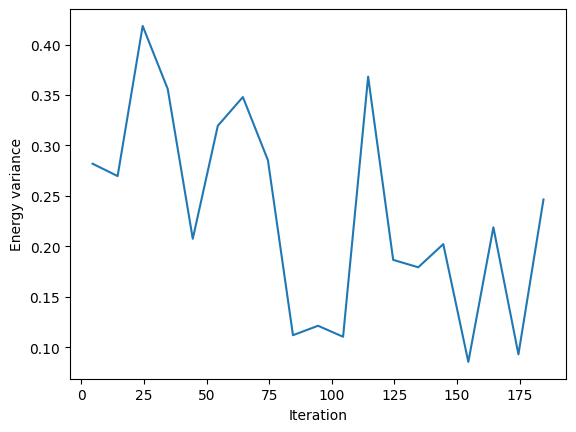

In [9]:
energy = qtx.utils.DataTracer()
VarE = qtx.utils.DataTracer()

for i in range(200):
    samples = sampler.sweep()
    step = optimizer.get_step(samples)
    state.update(step * 2e-3)

    energy.append(optimizer.energy)
    VarE.append(optimizer.VarE)

    if i % 10 == 0:
        clear_output(wait=True)
        energy.plot(batch=10, baseline=exact_energy)
        plt.xlabel("Iteration")
        plt.ylabel("Energy")
        plt.show()
        VarE.plot(batch=10)
        plt.xlabel("Iteration")
        plt.ylabel("Energy variance")
        plt.show()

state.save("/tmp/neural_jastrow.eqx")

Then we can check its accuracy against the exact ground state.

In [10]:
dense = state.todense(full_symm).normalize()

E = dense @ H @ dense
rel_err = abs(E - exact_energy) / abs(exact_energy)
print("Relative energy error:", jnp.asarray(rel_err))

fidelity = abs(dense @ exact_state) ** 2
print("Fidelity with exact ground state:", jnp.asarray(fidelity))

Relative energy error: 0.0003117542913034912
Fidelity with exact ground state: 0.9991177383591362
